In [3]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
from statsmodels.tsa.arima_model import ARIMA
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

import warnings
warnings.filterwarnings("ignore")

Importing plotly failed. Interactive plots will not work.


In [133]:
def predict_price(ticker, ml_model):
    
    start_date = '2019-01-01'

    today = datetime.date.today()
    yesterday = today - datetime.timedelta(days=1)
    end_date = yesterday

    panel_data = data.DataReader([ticker], 'yahoo', start_date, end_date)
    
    # ml model: auto arima, arima, prohphet, linear regression, LSTM
    if ml_model == 'auto arima':
        return ml_auto_arima(ticker, panel_data)
    elif ml_model == 'arima':
        return ml_arima(ticker, panel_data)
    elif ml_model == 'prophet':
        return ml_prophet(ticker, panel_data)
    elif ml_model == 'LSTM':
        return ml_LSTM(ticker, panel_data)

In [134]:
#test
predict_price('GOOGL', 'auto arima')

{'today_price': 2544.7403936860146,
 'yesterday_price': 2977.0400390625,
 'real_vs_prediction':              Prediction        GOOGL
 Date                                
 2021-04-15  2246.362544  2285.250000
 2021-04-16  2248.049376  2282.750000
 2021-04-19  2250.186913  2289.760010
 2021-04-20  2252.251004  2279.010010
 2021-04-21  2254.327064  2278.350098
 ...                 ...          ...
 2021-11-01  2534.368481  2869.939941
 2021-11-02  2536.442863  2908.649902
 2021-11-03  2538.517246  2931.959961
 2021-11-04  2540.591628  2965.350098
 2021-11-05  2542.666011  2977.040039
 
 [144 rows x 2 columns],
 'rmse': 63917.77938390901}

In [4]:
tickers = ['AAPL']

start_date = '2019-01-01'

today = datetime.date.today()
yesterday = today - datetime.timedelta(days=1)
end_date = yesterday

'''User pandas_reader.data.DataReader to load data'''
panel_data = data.DataReader(tickers, 'yahoo', start_date, end_date)


'''df = panel_data['Close']'''
df = panel_data
df.head()

Attributes,Adj Close,Close,High,Low,Open,Volume
Symbols,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2018-12-31,38.282612,39.435001,39.840000,39.119999,39.632500,140014000.0
2019-01-02,38.326290,39.480000,39.712502,38.557499,38.722500,148158800.0
2019-01-03,34.508709,35.547501,36.430000,35.500000,35.994999,365248800.0
2019-01-04,35.981861,37.064999,37.137501,35.950001,36.132500,234428400.0
2019-01-07,35.901775,36.982498,37.207500,36.474998,37.174999,219111200.0


# Auto ARIMA

In [9]:
from pmdarima import auto_arima

def ml_auto_arima(ticker, df):
    close = df['Close']
    
    #split data (train:test = 0.8:0.2)
    train_ratio = 0.8
    train_size = int(df.shape[0] * train_ratio)
    test_size = df.shape[0] - train_size

    train = close.head(train_size)
    test = close.tail(test_size)
    
    # training the model
    model = auto_arima(train, start_p=1, start_q=1,max_p=6, max_q=3, m=12, seasonal=True, error_action='ignore',suppress_warnings=True)
    model.fit(train)
    
    # prediction
    forecast = model.predict(n_periods=test_size+1)
    today_prediction = forecast[-1]
    forecast = pd.DataFrame(forecast[:-1],index = test.index,columns=['Prediction'])
    
    # combine test and forecast dataframes
    result = pd.concat([forecast, test], axis = 1)
    # result.plot()

    # calculating rmse 
    MSE_error = mean_squared_error(test, forecast)
    
    # output 
    return {'today_price': today_prediction, 'yesterday_price': test[ticker][-1], 'prediction': forecast, 'train': train, 'test':test, 'rmse': MSE_error}

In [10]:
#test
ml_auto_arima('AAPL', panel_data)

{'today_price': 155.93592321602952,
 'yesterday_price': 150.44000244140625,
 'prediction':             Prediction
 Date                  
 2021-04-15  132.541899
 2021-04-16  132.655632
 2021-04-19  132.823810
 2021-04-20  132.984543
 2021-04-21  133.146294
 ...                ...
 2021-11-02  155.127780
 2021-11-03  155.289408
 2021-11-04  155.451037
 2021-11-05  155.612666
 2021-11-08  155.774295
 
 [145 rows x 1 columns],
 'train': Symbols           AAPL
 Date                  
 2018-12-31   39.435001
 2019-01-02   39.480000
 2019-01-03   35.547501
 2019-01-04   37.064999
 2019-01-07   36.982498
 ...                ...
 2021-04-08  130.360001
 2021-04-09  133.000000
 2021-04-12  131.240005
 2021-04-13  134.429993
 2021-04-14  132.029999
 
 [576 rows x 1 columns],
 'test': Symbols           AAPL
 Date                  
 2021-04-15  134.500000
 2021-04-16  134.160004
 2021-04-19  134.839996
 2021-04-20  133.110001
 2021-04-21  133.500000
 ...                ...
 2021-11-02  150.020004

In [ ]:
# 5 days future price prediction
from pmdarima import auto_arima

close = df['Close']
# splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)

# train.plot()
# test.plot()

model = auto_arima(train, start_p=1, start_q=1,max_p=6, max_q=3, m=12, seasonal=True, error_action='ignore',suppress_warnings=True)
model.fit(train)

forecast = model.predict(n_periods=test_size+5)
today_prediction = forecast[-5:]
forecast = pd.DataFrame(forecast[:-5],index = test.index,columns=['Prediction'])
# forecast = pd.DataFrame(forecast,columns=['Prediction'])

result = pd.concat([forecast, test], axis = 1)
result.plot()

# calculating rmse
MSE_error = mean_squared_error(test, forecast)
print('Testing Mean Squared Error is {}'.format(MSE_error))

# ARIMA

In [20]:
def ml_arima(ticker, df):
    
    # preprocessing data
    train_data, test_data = df[0:int(len(df)*0.8)], df[int(len(df)*0.8):]
    train = train_data['Close']
    test = test_data['Close']
    training_data = train_data['Close'].values
    test_data = test_data['Close'].values
    history = [x for x in training_data]
    model_predictions = []
    N_test_observations = len(test_data)
    
    # train model
    for time_point in range(N_test_observations+1):
        try:
            model = ARIMA(history, order=(4,1,0))
            model_fit = model.fit(disp=0)
            output = model_fit.forecast()
            yhat = output[0]
            true_test_value = test_data[time_point]
            history.append(true_test_value)
            model_predictions.append(yhat)
        except:
            today_prediction = yhat
    
    model_predictions = pd.DataFrame(model_predictions, index = test.index, columns=['Prediction'])
    test_spare = pd.DataFrame(test_data, columns = [ticker])
    
    # combine test and forecast dataframes
    result = pd.concat([model_predictions, test_spare], axis = 1)

    # calculating rmse
    MSE_error = mean_squared_error(test, model_predictions)
    
    # output
    return {'today_price': today_prediction[0], 'yesterday_price': test_data[-1], 'prediction': model_predictions, 'train': train, 'test': test, 'rmse': MSE_error}

In [21]:
#test
ml_arima('AAPL', panel_data)

{'today_price': 150.7352430131002,
 'yesterday_price': array([150.44000244]),
 'prediction':             Prediction
 Date                  
 2021-04-15  132.598698
 2021-04-16  134.269200
 2021-04-19  134.453372
 2021-04-20  134.920006
 2021-04-21  133.529731
 ...                ...
 2021-11-02  149.023244
 2021-11-03  150.131497
 2021-11-04  151.577686
 2021-11-05  151.191262
 2021-11-08  151.337360
 
 [145 rows x 1 columns],
 'train': Symbols           AAPL
 Date                  
 2018-12-31   39.435001
 2019-01-02   39.480000
 2019-01-03   35.547501
 2019-01-04   37.064999
 2019-01-07   36.982498
 ...                ...
 2021-04-08  130.360001
 2021-04-09  133.000000
 2021-04-12  131.240005
 2021-04-13  134.429993
 2021-04-14  132.029999
 
 [576 rows x 1 columns],
 'test': Symbols           AAPL
 Date                  
 2021-04-15  134.500000
 2021-04-16  134.160004
 2021-04-19  134.839996
 2021-04-20  133.110001
 2021-04-21  133.500000
 ...                ...
 2021-11-02  150.0200

In [ ]:
# future 5 days prediction
from statsmodels.tsa.arima_model import ARIMA

train_data, test_data = df[0:int(len(df)*0.7)], df[int(len(df)*0.7):]
training_data = train_data['Close'].values
test_data = test_data['Close'].values
history = [x for x in training_data]
model_predictions = []
future = []
N_test_observations = len(test_data)
for time_point in range(N_test_observations+5):
    try:
        model = ARIMA(history, order=(4,1,0))
        model_fit = model.fit(disp=0)
        output = model_fit.forecast()
        yhat = output[0]
        true_test_value = test_data[time_point]
        history.append(true_test_value)
        model_predictions.append(yhat)
    except:
        future.append(yhat)
        history.append(yhat)
        model_predictions.append(yhat)
#         today_stock_price = yhat
MSE_error = mean_squared_error(test_data, model_predictions[:-5])
print('Testing Mean Squared Error is {}'.format(MSE_error))

In [ ]:
test_set_range = df[int(len(df)*0.7):].index
plt.plot(test_set_range, model_predictions, color='blue', marker='o', linestyle='dashed',label='Predicted Price')
plt.plot(test_set_range, test_data, color='red', label='Actual Price')
plt.title('AAPL Prices Prediction')
plt.xlabel('Date')
plt.ylabel('Prices')
# plt.xticks(np.arange(881,1259,50), df.Date[881:1259:50])
plt.legend()
plt.show()


#future predictions
print("Today's price prediction: ", yhat[0])

# Prophet

In [46]:
def ml_prophet(ticker, df):
    close = df['Close']

    #preparing data
    close.reset_index(inplace = True)
    close = close[['Date', ticker]]
    close.rename(columns={ticker: 'y', 'Date':'ds'}, inplace = True)

    #splitting the data
    train_ratio = 0.8
    train_size = int(df.shape[0] * train_ratio)
    test_size = df.shape[0] - train_size

    train = close.head(train_size)
    test = close.tail(test_size)

    #fit the model
    model = Prophet(daily_seasonality=True)
    model.fit(train)

    #predictions
    close_prices = model.make_future_dataframe(periods=len(test)+1)
    forecast = model.predict(close_prices)
    today_prediction = forecast['yhat'].to_list()[-1]
    
    # combine test and forecast dataframes
    forecast = pd.DataFrame(forecast,index = test.index,columns=['yhat'])
    result = pd.concat([forecast, test], axis = 1)
    
    #rmse
    forecast_valid = forecast['yhat'][-test_size:]
    MSE_error = mean_squared_error(test['y'], forecast_valid)
    
    # renaming columns in result
    result.rename(columns = {'yhat':'Prediction', 'y': ticker}, inplace = True)
    result.drop(columns = ['ds'], inplace = True)
    
    # formatting output
    forecast.rename(columns = {'yhat':'Prediction'}, inplace = True)
    train.rename(columns = {'y':ticker}, inplace = True)
    test.rename(columns = {'y':ticker}, inplace = True)
    train.set_index(['ds'], inplace = True)
    test.set_index(['ds'], inplace = True)
    
    # output
    return {'today_price': today_prediction, 'yesterday_price': test[ticker].to_list()[-1], 'prediction':forecast, 'train':train, 'test':test, 'rmse': MSE_error}

In [47]:
#test
ml_prophet('AAPL', panel_data)

{'today_price': 142.78549876665852,
 'yesterday_price': 150.44000244140625,
 'prediction':      Prediction
 576  126.911510
 577  126.927026
 578  129.237405
 579  129.347536
 580  127.420281
 ..          ...
 716  144.852981
 717  144.381901
 718  146.171500
 719  145.732565
 720  143.234485
 
 [145 rows x 1 columns],
 'train': Symbols           AAPL
 ds                    
 2018-12-31   39.435001
 2019-01-02   39.480000
 2019-01-03   35.547501
 2019-01-04   37.064999
 2019-01-07   36.982498
 ...                ...
 2021-04-08  130.360001
 2021-04-09  133.000000
 2021-04-12  131.240005
 2021-04-13  134.429993
 2021-04-14  132.029999
 
 [576 rows x 1 columns],
 'test': Symbols           AAPL
 ds                    
 2021-04-15  134.500000
 2021-04-16  134.160004
 2021-04-19  134.839996
 2021-04-20  133.110001
 2021-04-21  133.500000
 ...                ...
 2021-11-02  150.020004
 2021-11-03  151.490005
 2021-11-04  150.960007
 2021-11-05  151.279999
 2021-11-08  150.440002
 
 [145 row

In [ ]:
# suppose to predict 5 days (work in progress)
from prophet import Prophet

close = df['Close']

#preparing data
close.reset_index(inplace = True)
close = close[['Date', 'AAPL']]
close.rename(columns={'AAPL': 'y', 'Date':'ds'}, inplace = True)

#splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(test_size)

#fit the model
model = Prophet(daily_seasonality=True)
model.fit(train)

#predictions
close_prices = model.make_future_dataframe(periods=len(test))
forecast = model.predict(close_prices)

#rmse
forecast_valid = forecast['yhat'][-test_size:]
MSE_error = mean_squared_error(test['y'], forecast_valid)
print('Testing Mean Squared Error is {}'.format(MSE_error))

#plot
test['Predictions'] = 0
test['Predictions'] = forecast_valid.values

# plt.plot(train['y'])
plt.plot(test['y'], color = 'blue', label = 'Actual Price')
plt.plot(test['Predictions'], color = 'red', label = 'Predicted Price')
plt.title('AAPL Prices Prediction')
plt.xlabel('Date')
plt.ylabel('Prices')
plt.legend()
plt.show()

# LSTM

In [7]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

In [38]:
def ml_LSTM(ticker, df):
    close = df['Close']

    #splitting the data
    train_ratio = 0.8
    train_size = int(df.shape[0] * train_ratio)
    test_size = df.shape[0] - train_size

    train = close.head(train_size)
    test = close.tail(-test_size)

    #preparing data
    close.reset_index(inplace = True)
    close = close[['Date', ticker]]
    close.drop('Date', axis=1, inplace = True)

    #convert into x and y
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(close)

    x_train, y_train = [], []
    for i in range(60,len(train)):
        x_train.append(scaled_data[i-60:i,0])
        y_train.append(scaled_data[i,0])
    x_train, y_train = np.array(x_train), np.array(y_train)
    x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

    # create and fit the LSTM network
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
    model.add(LSTM(units=50))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer='adam')
    model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

    #prediction
    inputs = close[len(close) - len(test) - 60:].values
    inputs = inputs.reshape(-1,1)
    inputs  = scaler.transform(inputs)

    X_test = []
    for i in range(60,inputs.shape[0]+1):
        X_test.append(inputs[i-60:i,0])
    X_test = np.array(X_test)

    X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
    closing_price = model.predict(X_test)
    closing_price = scaler.inverse_transform(closing_price)
    today_prediction = closing_price[-1]
    closing_price = closing_price[:-1]
    yesterday_price = closing_price[-1]

    #rmse
    MSE_error = mean_squared_error(test[ticker], closing_price)
    MSE_error
    
    #combine test and prediction dataframe
    #test['Predictions'] = closing_price
    #test.drop(columns = ['Date'], inplace = True)
    
    # creating dataframe for prediction
    closing_price = pd.DataFrame(closing_price, index=test.index, columns = ['Prediction'])
    
    # output
    return {'today_price': today_prediction[0], 'yesterday_price': yesterday_price, 'prediction': closing_price, 'train': train, 'test': test, 'rmse': MSE_error}

In [39]:
# test
ml_LSTM('AAPL', panel_data)

516/516 - 7s - loss: 0.0039


{'today_price': 135.2762,
 'yesterday_price': array([135.15463], dtype=float32),
 'prediction':             Prediction
 Date                  
 2019-07-30   48.974430
 2019-07-31   49.094028
 2019-08-01   49.259422
 2019-08-02   49.380310
 2019-08-05   49.402969
 ...                ...
 2021-11-02  134.387177
 2021-11-03  134.564590
 2021-11-04  134.779175
 2021-11-05  134.971436
 2021-11-08  135.154633
 
 [576 rows x 1 columns],
 'train': Symbols           AAPL
 Date                  
 2018-12-31   39.435001
 2019-01-02   39.480000
 2019-01-03   35.547501
 2019-01-04   37.064999
 2019-01-07   36.982498
 ...                ...
 2021-04-08  130.360001
 2021-04-09  133.000000
 2021-04-12  131.240005
 2021-04-13  134.429993
 2021-04-14  132.029999
 
 [576 rows x 1 columns],
 'test': Symbols           AAPL
 Date                  
 2019-07-30   52.195000
 2019-07-31   53.259998
 2019-08-01   52.107498
 2019-08-02   51.005001
 2019-08-05   48.334999
 ...                ...
 2021-11-02  150.0

In [66]:
close = df['Close']

#preparing data
close.reset_index(inplace = True)
close = close[['Date', 'AAPL']]
# close = close.values

#splitting the data
train_ratio = 0.8
train_size = int(df.shape[0] * train_ratio)
test_size = df.shape[0] - train_size

train = close.head(train_size)
test = close.tail(-test_size)

close.drop('Date', axis=1, inplace = True)

#convert into x and y
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close)

x_train, y_train = [], []
for i in range(60,len(train)):
    x_train.append(scaled_data[i-60:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

#prediction
inputs = close[len(close) - len(test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)

X_test = []
for i in range(60,inputs.shape[0]+1):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)
today_price = closing_price[-1]
closing_price = closing_price[:-1]

#rmse
MSE_error = mean_squared_error(test['AAPL'], closing_price)
MSE_error

#for plotting
test['Predictions'] = closing_price
plt.plot(train['AAPL'])
plt.plot(test[['AAPL','Predictions']])
plt.legend()
plt.plot()

516/516 - 7s - loss: 0.0044


36.416483877473055

No handles with labels found to put in legend.


[]

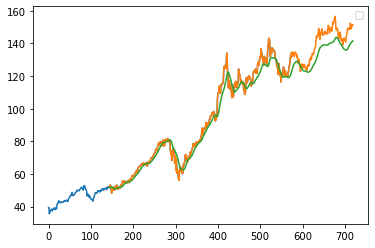

In [36]:
#for plotting
test['Predictions'] = closing_price
plt.plot(train['AAPL'])
plt.plot(test[['AAPL','Predictions']])
plt.legend()
plt.plot()

In [46]:
len(closing_price)

576